In [ ]:
# ============================================================
# CNN + SOFT RULE-BASED SKIN LESION CLASSIFIER (ONE CELL)
# ============================================================

# -------------------- INSTALLS --------------------
%pip install -q kagglehub scikit-image torch torchvision tqdm opencv-python matplotlib

# -------------------- IMPORTS --------------------
import os, glob, cv2, itertools, numpy as np, pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# -------------------- DEVICE --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------- DOWNLOAD DATASET --------------------
import kagglehub
dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset path:", dataset_path)

# -------------------- LOAD METADATA --------------------
metadata = pd.read_csv(os.path.join(dataset_path, "HAM10000_metadata.csv"))
image_paths = {}
for folder in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
    for img in glob.glob(os.path.join(dataset_path, folder, "*.jpg")):
        image_paths[os.path.basename(img).split(".")[0]] = img
metadata["path"] = metadata["image_id"].map(image_paths)
metadata = metadata.dropna()
metadata["label"] = pd.Categorical(metadata["dx"]).codes
metadata["label"] = metadata["label"].astype("int64")
class_names = list(pd.Categorical(metadata["dx"]).categories)
num_classes = len(class_names)
print("Classes:", class_names)

# -------------------- SPLIT DATA --------------------
df_train, df_tmp = train_test_split(metadata, test_size=0.2, stratify=metadata["label"], random_state=42)
df_val, df_test = train_test_split(df_tmp, test_size=0.5, stratify=df_tmp["label"], random_state=42)
print(len(df_train), len(df_val), len(df_test))

# -------------------- DATASET --------------------
class SkinDataset(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True)
        self.tf = tf
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx,"path"]).convert("RGB")
        label = torch.tensor(self.df.loc[idx,"label"], dtype=torch.long)
        return self.tf(img), label

# -------------------- TRANSFORMS --------------------
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# -------------------- DATALOADERS --------------------
train_loader = DataLoader(SkinDataset(df_train, train_tf), batch_size=32, shuffle=True)
val_loader   = DataLoader(SkinDataset(df_val, val_tf), batch_size=32, shuffle=False)
test_loader  = DataLoader(SkinDataset(df_test, val_tf), batch_size=32, shuffle=False)

# -------------------- MODEL --------------------
model = models.resnet50(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -------------------- TRAINING FUNCTIONS --------------------
def train_epoch(loader):
    model.train()
    total_loss = 0
    for X,y in tqdm(loader, leave=False):
        X,y = X.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(loader):
    model.eval()
    correct, total = 0,0
    with torch.no_grad():
        for X,y in loader:
            X,y = X.to(device), y.to(device)
            preds = model(X).argmax(1)
            correct += (preds==y).sum().item()
            total += y.size(0)
    return correct / total

# -------------------- TRAIN MODEL --------------------
num_epochs = 15
train_losses, val_accs = [], []
for epoch in range(num_epochs):
    loss = train_epoch(train_loader)
    acc  = eval_epoch(val_loader)
    train_losses.append(loss)
    val_accs.append(acc)
    print(f"Epoch {epoch+1}: loss={loss:.4f} val_acc={acc:.4f}")

# -------------------- TEST EVALUATION --------------------
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for X,y in test_loader:
        X = X.to(device)
        preds = model(X).argmax(1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(y.numpy())

print("\nCNN Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# -------------------- RULE-BASED MODEL (ABCD) --------------------
def abcd_rule_based(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return 0
    c = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(c)
    x,y,w,h = cv2.boundingRect(c)
    aspect_ratio = w/h
    # softer thresholds
    if area>8000 or aspect_ratio<0.6 or aspect_ratio>1.4:
        return 1
    return 0



Device: cuda
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset path: /kaggle/input/skin-cancer-mnist-ham10000
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
7966 996 996


Epoch 1: loss=0.6544 val_acc=0.8122


Epoch 2: loss=0.4711 val_acc=0.8273


Epoch 3: loss=0.3999 val_acc=0.8404


Epoch 4: loss=0.3394 val_acc=0.8454


...

Epoch 12: loss=0.1073 val_acc=0.8474


Epoch 13: loss=0.1203 val_acc=0.8735


Epoch 14: loss=0.0958 val_acc=0.8404


Epoch 15: loss=0.1074 val_acc=0.8554

CNN Classification Report:
              precision    recall  f1-score   support

       akiec       0.52      0.88      0.65        33
         bcc       0.87      0.75      0.80        52
         bkl       0.78      0.77      0.77       109
          df       0.53      0.73      0.62        11
         mel       0.79      0.63      0.70       111
          nv       0.94      0.94      0.94       666
        vasc       0.82      1.00      0.90        14

    accuracy                           0.87       996
   macro avg       0.75      0.81      0.77       996
weighted avg       0.88      0.87      0.87       996



RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [ ]:
hybrid_preds = []
malignant_classes = ["mel","bcc","akiec"]

for idx, row in df_test.iterrows():
    img_tensor = val_tf(Image.open(row["path"]).convert("RGB")).unsqueeze(0).to(device)

    # Detach from graph to convert to numpy
    cnn_probs = torch.softmax(model(img_tensor), dim=1)[0].detach().cpu().numpy()

    rule_score = abcd_rule_based(row["path"])  # 0/1

    # Boost probabilities of malignant classes if rule says suspicious
    if rule_score==1:
        for c in malignant_classes:
            cnn_probs[class_names.index(c)] += 0.2  # small boost
        cnn_probs = cnn_probs / cnn_probs.sum()  # renormalize

    final_pred = cnn_probs.argmax()
    hybrid_preds.append(final_pred)



Hybrid Classification Report (Soft Boost):
              precision    recall  f1-score   support

       akiec       0.49      0.88      0.63        33
         bcc       0.85      0.77      0.81        52
         bkl       0.81      0.76      0.79       109
          df       0.54      0.64      0.58        11
         mel       0.77      0.70      0.74       111
          nv       0.95      0.94      0.94       666
        vasc       0.88      1.00      0.93        14

    accuracy                           0.88       996
   macro avg       0.76      0.81      0.77       996
weighted avg       0.89      0.88      0.88       996



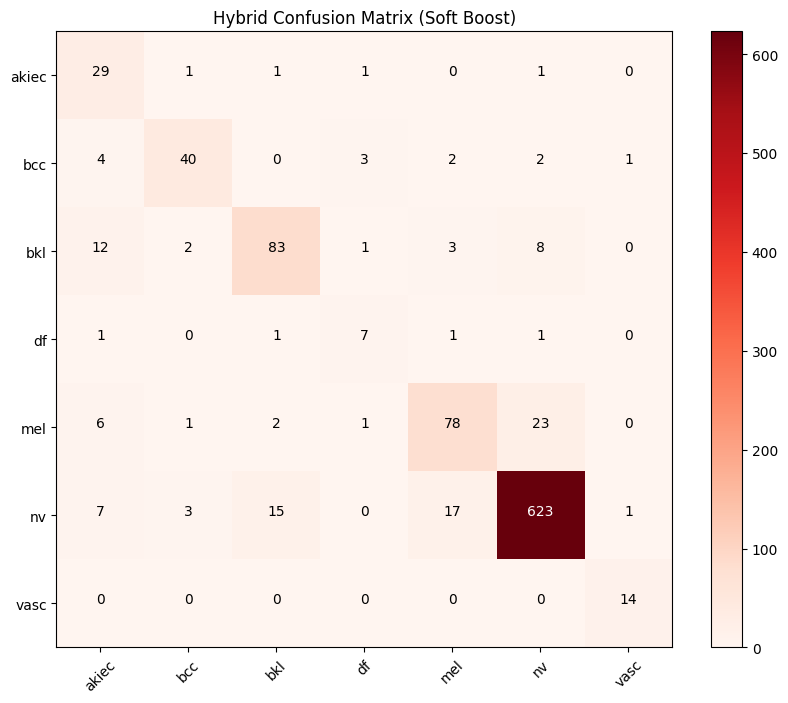

In [ ]:
y_true_h = [row["label"] for idx,row in df_test.iterrows()]
print("\nHybrid Classification Report (Soft Boost):")
print(classification_report(y_true_h, hybrid_preds, target_names=class_names))

cm_h = confusion_matrix(y_true_h, hybrid_preds)
plt.figure(figsize=(10,8))
plt.imshow(cm_h, interpolation='nearest', cmap=plt.cm.Reds)
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)
for i,j in itertools.product(range(cm_h.shape[0]), range(cm_h.shape[1])):
    plt.text(j,i,format(cm_h[i,j],'d'), ha="center", color="white" if cm_h[i,j]>cm_h.max()/2 else "black")
plt.title("Hybrid Confusion Matrix (Soft Boost)")
plt.show()

In [ ]:
torch.save(model, "skin_lesion_model.pth")
